# ПГО на основании анализа исторических данных

## Что мы хотим
- построить алгоритм поиска грубых ошибок на основе ИИ техник
- решать задачу ПГО быстро

In [4]:
%load_ext autoreload
%autoreload 2

#import warnings
#warnings.filterwarnings('ignore')
import sys, os

import holoviews as hv

from datetime import datetime
import pandas as pd
from IPython.display import Image
import numpy as np
import matplotlib.pyplot as plt
import random
import itertools

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from src.graph_generator import GraphGenerator
from src.tools import build_sunkey_links
pd.set_option('display.precision', 2)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Данные

### Визуализация графа

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
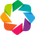

:Sankey   [Source,Target]   (Value)

In [5]:
gg = GraphGenerator(layer_sizes=[5, 10, 3])
gg.build()
g = gg.fill_with_values(1000)

hv.extension('bokeh')
d = build_sunkey_links(g)
sankey = hv.Sankey(d)
#sankey
sankey.opts(width=1000, height=400)

In [7]:
g.edges


{'env -> 0:0': <src.graph_base.Edge at 0x219b280a870>,
 '0:0 -> 1:2': <src.graph_base.Edge at 0x219b280af60>,
 'env -> 0:1': <src.graph_base.Edge at 0x219b280a0c0>,
 '0:1 -> 1:8': <src.graph_base.Edge at 0x219b280a810>,
 'env -> 0:2': <src.graph_base.Edge at 0x219b280b320>,
 '0:2 -> 1:9': <src.graph_base.Edge at 0x219b280aab0>,
 'env -> 0:3': <src.graph_base.Edge at 0x219b280ad80>,
 '0:3 -> 1:9': <src.graph_base.Edge at 0x219b280b0b0>,
 'env -> 0:4': <src.graph_base.Edge at 0x219b280ae40>,
 '0:4 -> 1:1': <src.graph_base.Edge at 0x219b280aa20>,
 '0:3 -> 1:0': <src.graph_base.Edge at 0x219b280afc0>,
 '1:0 -> 2:2': <src.graph_base.Edge at 0x219b280ae10>,
 '1:1 -> 2:0': <src.graph_base.Edge at 0x219b280a960>,
 '1:2 -> 2:2': <src.graph_base.Edge at 0x219b280b1a0>,
 '0:2 -> 1:3': <src.graph_base.Edge at 0x219b280b020>,
 '1:3 -> 2:2': <src.graph_base.Edge at 0x219b280b230>,
 '0:1 -> 1:4': <src.graph_base.Edge at 0x219b280ad50>,
 '1:4 -> 2:2': <src.graph_base.Edge at 0x219b280b050>,
 '0:2 -> 1

### Построение графа

In [62]:
test_cases_fraction = .25
train_dataset_len = 20_000
initial_volume = 1_000

df = pd.concat([
    gg.build_pivot_table(train_dataset_len, initial_env_volume=initial_volume, ratio=0.2), 
    gg.build_pivot_table(int(train_dataset_len * test_cases_fraction), initial_env_volume=initial_volume, ratio=0.2)
])
df.head()

,env -> 0:0,0:0 -> 1:3,env -> 0:1,0:1 -> 1:9,env -> 0:2,0:2 -> 1:4,env -> 0:3,0:3 -> 1:9,env -> 0:4,0:4 -> 1:1,...,0:3 -> 1:6_diff,1:6 -> 2:0_diff,0:3 -> 1:7_diff,1:7 -> 2:0_diff,0:2 -> 1:8_diff,1:8 -> 2:1_diff,1:9 -> 2:0_diff,2:0 -> env_diff,2:1 -> env_diff,2:2 -> env_diff
0,438.35,329.06,1.92,0.70,180.43,77.68,224.92,68.83,69.87,74.91,...,0.00,-18.69,0.00,0.0,0.00,0.00,0.69,0.0,0.00,0.0
1,35.21,21.73,6.85,4.59,210.51,72.84,182.42,79.10,289.84,91.36,...,0.00,-1.78,35.24,0.0,0.00,0.00,-38.93,0.0,0.00,0.0
2,196.31,196.31,167.79,78.69,257.82,142.68,38.81,23.53,100.49,118.93,...,0.00,0.00,0.00,0.0,0.00,-4.61,0.00,0.0,196.24,0.0
3,69.86,96.08,217.94,123.51,68.51,25.56,98.18,5.77,195.08,92.26,...,26.37,0.00,0.00,0.0,-4.32,0.00,0.00,0.0,0.00,0.0
4,133.49,133.49,150.68,114.39,53.81,27.09,212.36,82.36,60.69,23.45,...,0.00,0.00,-41.16,0.0,0.00,0.00,0.00,0.0,-29.68,0.0


In [63]:
flow_names = list(gg.graph.edges.keys())
nodes_names =list(gg.graph.nodes.keys())
x_cols = flow_names + nodes_names
y_cols = [col+'_diff' for col in x_cols if col in flow_names]

print(f'количество потоков      : ', len(flow_names))
print(f'количество узлов        : ', len(nodes_names))
print(f'средняя связность графа :  {(len(flow_names) / len(nodes_names)):.1f}')
print(f'x columns               :  {x_cols[:5]}...')
print(f'y columns               :  {y_cols[:5]}...')
print(f'x columns num           :  {len(x_cols)}')
print(f'y columns num           :  {len(y_cols)}')

количество потоков      :  29
количество узлов        :  19
средняя связность графа :  1.5
x columns               :  ['env -> 0:0', '0:0 -> 1:3', 'env -> 0:1', '0:1 -> 1:9', 'env -> 0:2']...
y columns               :  ['env -> 0:0_diff', '0:0 -> 1:3_diff', 'env -> 0:1_diff', '0:1 -> 1:9_diff', 'env -> 0:2_diff']...
x columns num           :  48
y columns num           :  29


### Делим выборку на тренировочную, валидационную и тестовую

In [64]:
from sklearn.model_selection import train_test_split
df_train, df_test = df[:train_dataset_len], df[train_dataset_len:] 
df_train, df_val = train_test_split(df.sample(len(df_train)), test_size=1/4)

print(f'В тренировочной выборке :  {len(df_train)} строк')
print(f'В валидационной выборке :  {len(df_val)} строк')
print(f'В тестовой выборке      :  {len(df_test)}  строк')

df_train_x, df_train_y = df_train[x_cols], df_train[y_cols]
df_val_x, df_val_y = df_val[x_cols], df_val[y_cols]
df_test_x, df_test_y = df_test[x_cols], df_test[y_cols]

В тренировочной выборке :  15000 строк
В валидационной выборке :  5000 строк
В тестовой выборке      :  5000  строк


# Препроцессинг

In [65]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

mms = MinMaxScaler((0, 100))

df_train_sc = pd.DataFrame(mms.fit_transform(X=df_train), columns=df_train.columns)  # заменимь на df_train_x
df_test_sc = pd.DataFrame(mms.transform(X=df_test), columns=df_train.columns)
df_val_sc = pd.DataFrame(mms.transform(X=df_val), columns=df_train.columns)

# sklearn quantile transform
# todo попробовать полиноимальные фичи

df_train_x_sc, df_train_y_sc = df_train_sc[x_cols], df_train_sc[y_cols]
df_val_x_sc, df_val_y_sc = df_val_sc[x_cols], df_val_sc[y_cols]
df_test_x_sc, df_test_y_sc = df_test_sc[x_cols], df_test_sc[y_cols]

(array([4.0000e+00, 1.8000e+01, 1.9000e+02, 1.0610e+03, 1.2387e+04,
        1.0670e+03, 2.3200e+02, 3.4000e+01, 4.0000e+00, 3.0000e+00]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

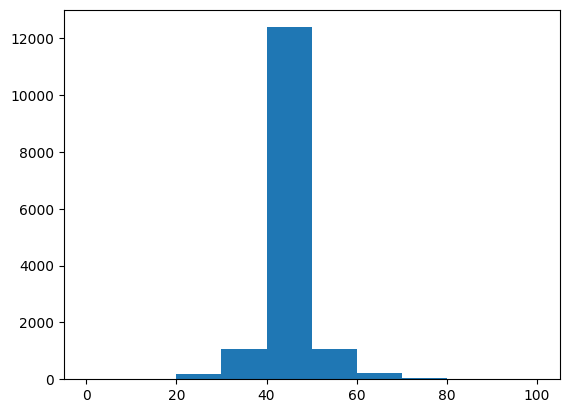

In [66]:
plt.hist(df_train_sc['0:0'])

In [67]:
max_y_cols = 10
y_cols_batches = np.array_split(y_cols, np.ceil(len(y_cols) / max_y_cols))

In [78]:
def build_mod(df_train_x, df_train_y):
    input_dim = df_train_x.shape[1]
    output_dim = df_train_y.shape[1]

    mod = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)), 
        tf.keras.layers.Dense(input_dim * 5, activation='relu'), 
        tf.keras.layers.Dense(input_dim * 4, activation='relu'), 
        tf.keras.layers.Dense(input_dim * 3, activation='relu'),
        tf.keras.layers.Dense(input_dim * 2, activation='relu'),
        tf.keras.layers.Dense(output_dim * 2, activation='relu'),
        tf.keras.layers.Dense(output_dim, activation='linear')
    ])
    
    mod.compile(
        optimizer='adam', 
        loss="mean_squared_error") #"mae"

    return mod


def fit(mod, df_train_x, df_train_y, df_val_x, df_val_y):
    
    BATCH_SIZE = 128
    EPOCHS = 200
    
    yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')
    log_subdir = f"{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(mod.layers)}"
    
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        verbose=1, 
        mode='min',
        restore_best_weights=True,
        min_delta=.1
    )
    #todo добавить батч нормализацию
    cb = [early_stop]
    
    history = mod.fit(
        df_train_x, df_train_y,
        shuffle=True,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=cb,
        validation_data=(df_val_x, df_val_y)
    )

In [87]:
print(f'всего {len(y_cols_batches)} батчей y колонок')
preds = []
for ind, y_cols_tmp in enumerate(y_cols_batches):
    print(f'обработка батча {ind+1}...')
    mod = build_mod(df_train_x, df_train_y[y_cols_tmp])
    fit(mod, df_train_x_sc, df_train_y_sc[y_cols_tmp], df_val_x_sc, df_val_y_sc[y_cols_tmp])
    prd = mod.predict(df_test_x_sc)
    preds.append(pd.DataFrame(prd, columns=y_cols_tmp))

всего 3 батчей y колонок
обработка батча 1...
Epoch 1/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1073.0262 - val_loss: 18.8513
Epoch 2/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.6991 - val_loss: 17.4632
Epoch 3/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.9632 - val_loss: 15.1860
Epoch 4/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.6809 - val_loss: 13.6693
Epoch 5/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13.4902 - val_loss: 13.2354
Epoch 6/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13.1131 - val_loss: 13.0726
Epoch 7/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13.1668 - val_loss: 13.1029
Epoch 8/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.8182 - val_loss: 12.9102
Epoch 9/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.6181 - val_loss: 12.4804
Epoch 10/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.6066 - val_loss: 13.5371
Epoch 11/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss:

In [92]:
pred_df = pd.concat(preds, axis=1)
pred_df.head()

,env -> 0:0_diff,0:0 -> 1:3_diff,env -> 0:1_diff,0:1 -> 1:9_diff,env -> 0:2_diff,0:2 -> 1:4_diff,env -> 0:3_diff,0:3 -> 1:9_diff,env -> 0:4_diff,0:4 -> 1:1_diff,...,0:3 -> 1:6_diff,1:6 -> 2:0_diff,0:3 -> 1:7_diff,1:7 -> 2:0_diff,0:2 -> 1:8_diff,1:8 -> 2:1_diff,1:9 -> 2:0_diff,2:0 -> env_diff,2:1 -> env_diff,2:2 -> env_diff
0,43.38,52.87,49.08,39.62,38.34,34.35,53.52,51.35,52.79,43.95,...,48.82,50.58,57.89,44.96,39.47,46.83,62.29,48.03,51.04,54.04
1,43.90,52.94,48.51,40.81,39.00,34.72,54.86,52.04,52.22,44.78,...,45.93,52.63,58.07,44.80,37.82,47.52,52.72,15.66,51.17,54.83
2,35.65,52.51,48.26,39.34,39.43,33.76,53.67,50.93,52.13,48.57,...,48.32,49.30,60.08,47.58,42.31,46.23,52.23,48.44,51.48,54.35
3,45.24,65.76,51.35,41.75,38.07,36.35,54.35,53.99,52.38,44.82,...,48.42,54.09,59.77,44.91,39.02,49.19,53.19,48.24,30.09,54.44
4,45.06,24.90,47.81,40.50,39.54,33.17,53.76,51.59,52.54,48.34,...,48.35,47.74,57.72,45.73,40.70,44.85,53.72,48.38,51.08,54.63


In [93]:
df_test_y_sc_pred = pd.concat([df_test_x_sc, pred_df], axis=1)
df_test_y_sc_pred.head(3)

,env -> 0:0,0:0 -> 1:3,env -> 0:1,0:1 -> 1:9,env -> 0:2,0:2 -> 1:4,env -> 0:3,0:3 -> 1:9,env -> 0:4,0:4 -> 1:1,...,0:3 -> 1:6_diff,1:6 -> 2:0_diff,0:3 -> 1:7_diff,1:7 -> 2:0_diff,0:2 -> 1:8_diff,1:8 -> 2:1_diff,1:9 -> 2:0_diff,2:0 -> env_diff,2:1 -> env_diff,2:2 -> env_diff
0,27.95,37.51,4.32,3.77,3.19,3.85,41.58,28.53,1.36,0.99,...,48.82,50.58,57.89,44.96,39.47,46.83,62.29,48.03,51.04,54.04
1,23.96,32.16,15.69,11.25,12.45,16.71,39.39,25.79,21.74,9.06,...,45.93,52.63,58.07,44.80,37.82,47.52,52.72,15.66,51.17,54.83
2,14.86,27.30,14.94,8.09,7.66,9.36,13.66,2.20,1.34,1.54,...,48.32,49.30,60.08,47.58,42.31,46.23,52.23,48.44,51.48,54.35


In [94]:
df_test_y_pred = mms.inverse_transform(df_test_y_sc_pred)
df_test_y_pred = pd.DataFrame(df_test_y_pred, columns=df.columns)
df_test_y_pred.index = df_test.index
df_test_y_pred.head()

,env -> 0:0,0:0 -> 1:3,env -> 0:1,0:1 -> 1:9,env -> 0:2,0:2 -> 1:4,env -> 0:3,0:3 -> 1:9,env -> 0:4,0:4 -> 1:1,...,0:3 -> 1:6_diff,1:6 -> 2:0_diff,0:3 -> 1:7_diff,1:7 -> 2:0_diff,0:2 -> 1:8_diff,1:8 -> 2:1_diff,1:9 -> 2:0_diff,2:0 -> env_diff,2:1 -> env_diff,2:2 -> env_diff
0,303.93,303.93,35.59,22.83,36.32,19.83,294.26,115.21,10.87,5.15,...,2.62,1.21,-0.92,1.03,1.05,-0.62,34.71,2.96,1.19,-1.26
1,260.54,260.54,129.31,68.09,141.74,86.06,278.73,104.12,173.39,47.28,...,-4.31,6.50,-0.48,0.65,-3.43,1.40,-1.10,-186.01,2.09,2.13
2,161.62,221.15,123.11,48.95,87.22,48.19,96.65,8.89,10.70,8.02,...,1.43,-2.10,4.44,7.18,8.79,-2.37,-2.94,5.32,4.18,0.06
3,136.01,192.44,293.12,143.81,265.99,18.23,81.92,29.37,216.20,80.37,...,1.67,10.26,3.67,0.90,-0.18,6.30,0.66,4.18,-142.33,0.47
4,372.42,237.72,113.49,22.86,74.90,10.67,198.59,145.50,94.23,9.59,...,1.49,-6.11,-1.33,2.82,4.39,-6.42,2.64,4.98,1.47,1.29


4463


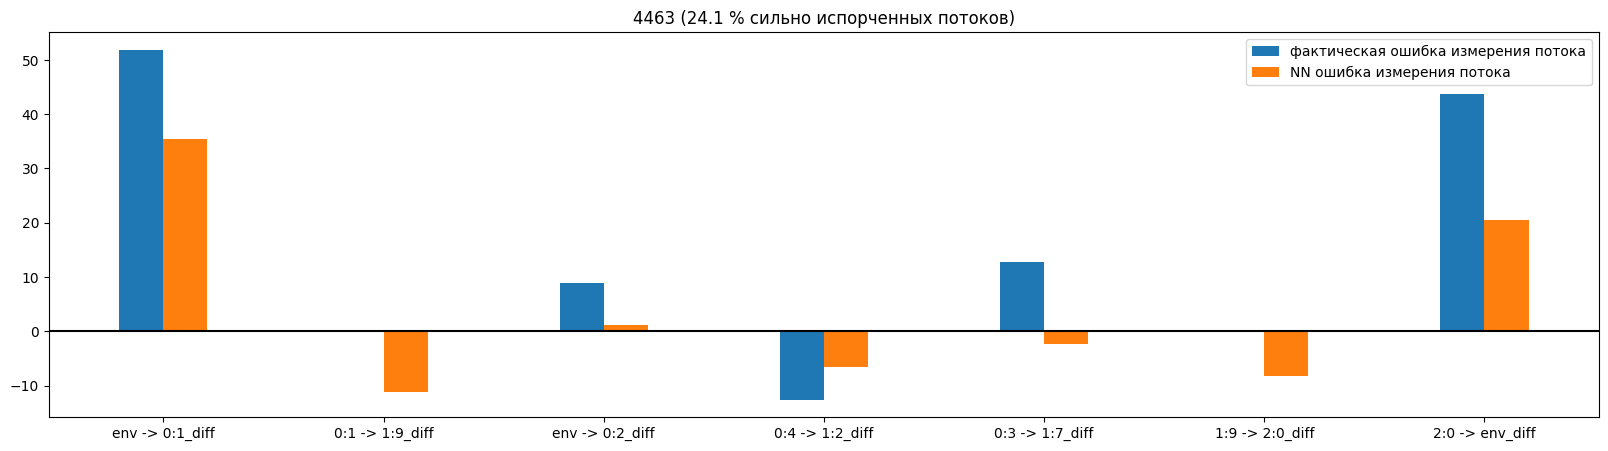

4696


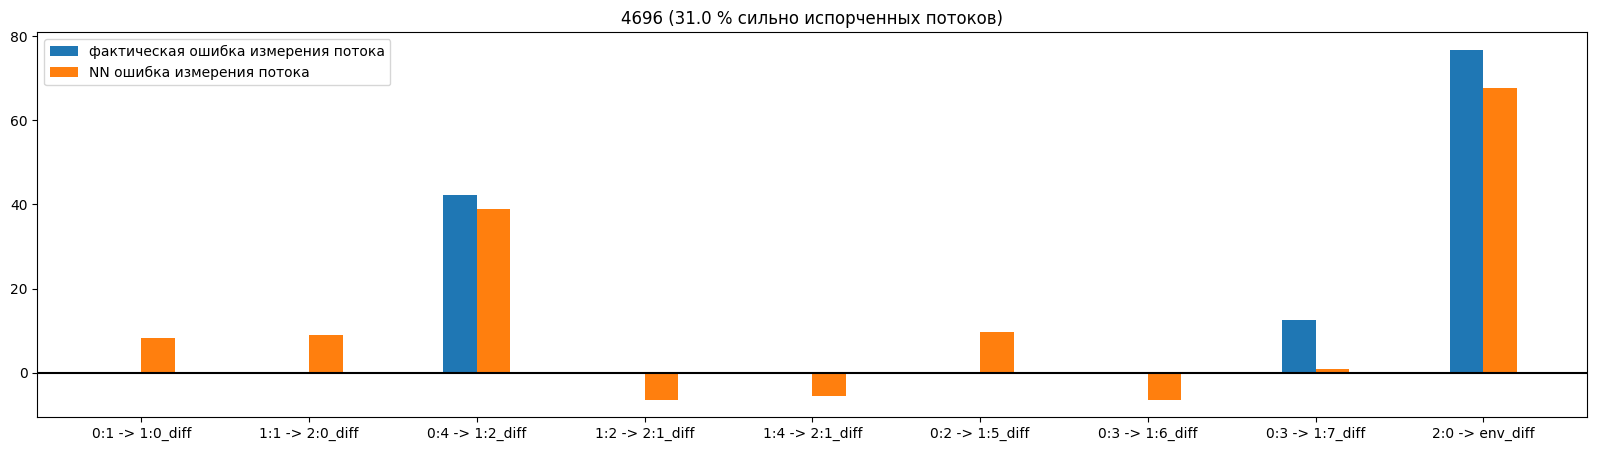

1503


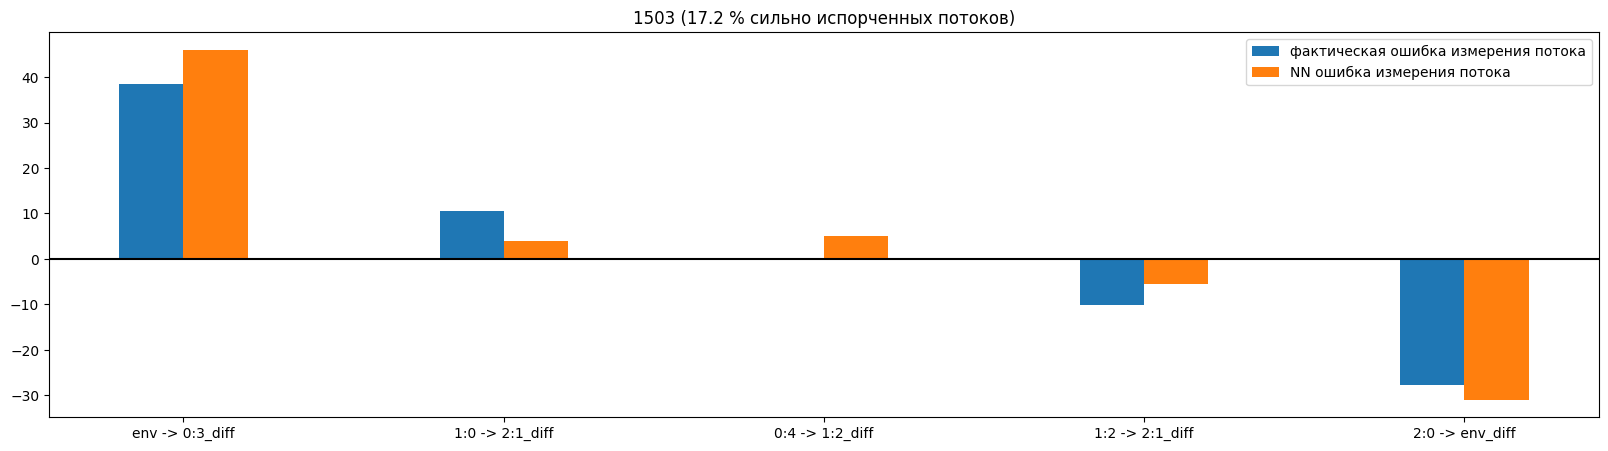

721


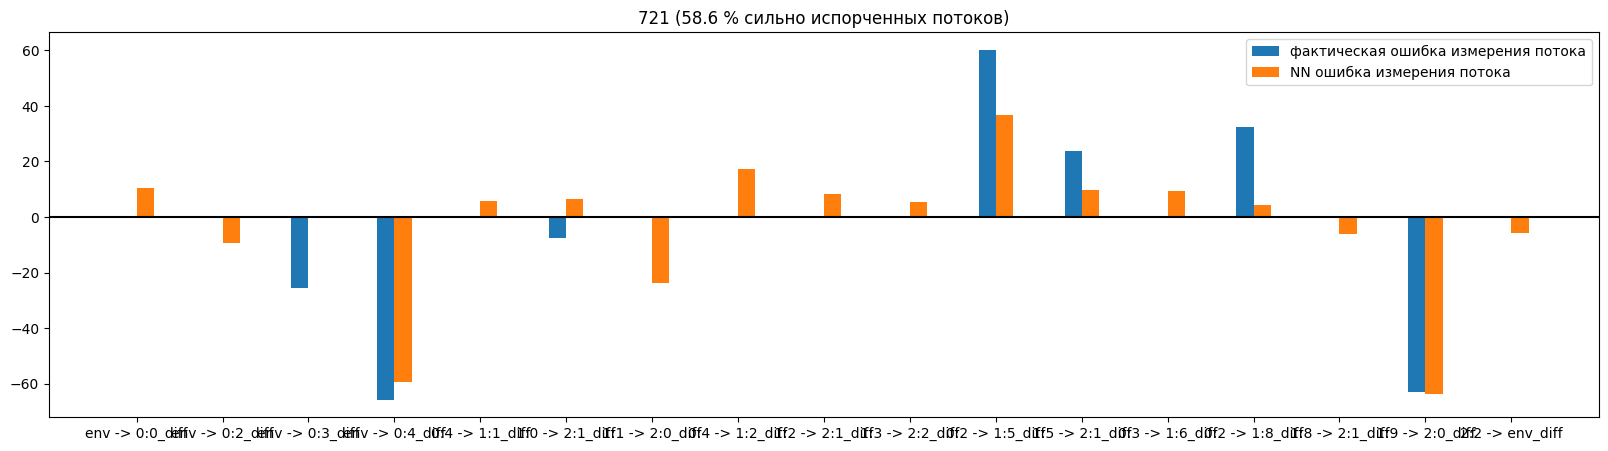

4434


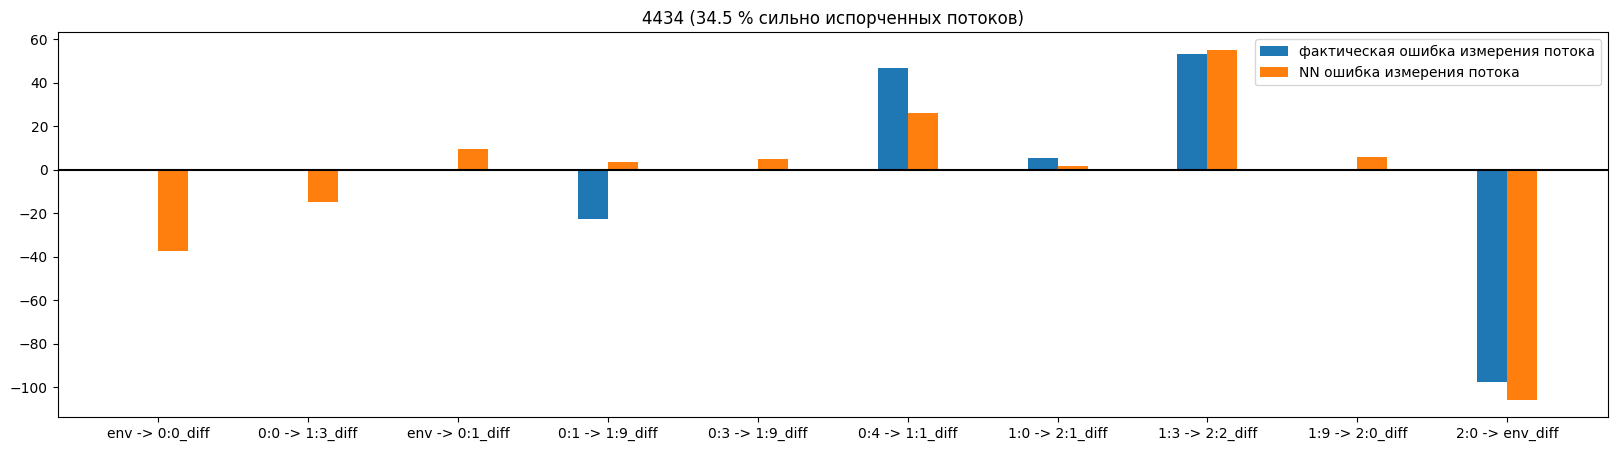

3317


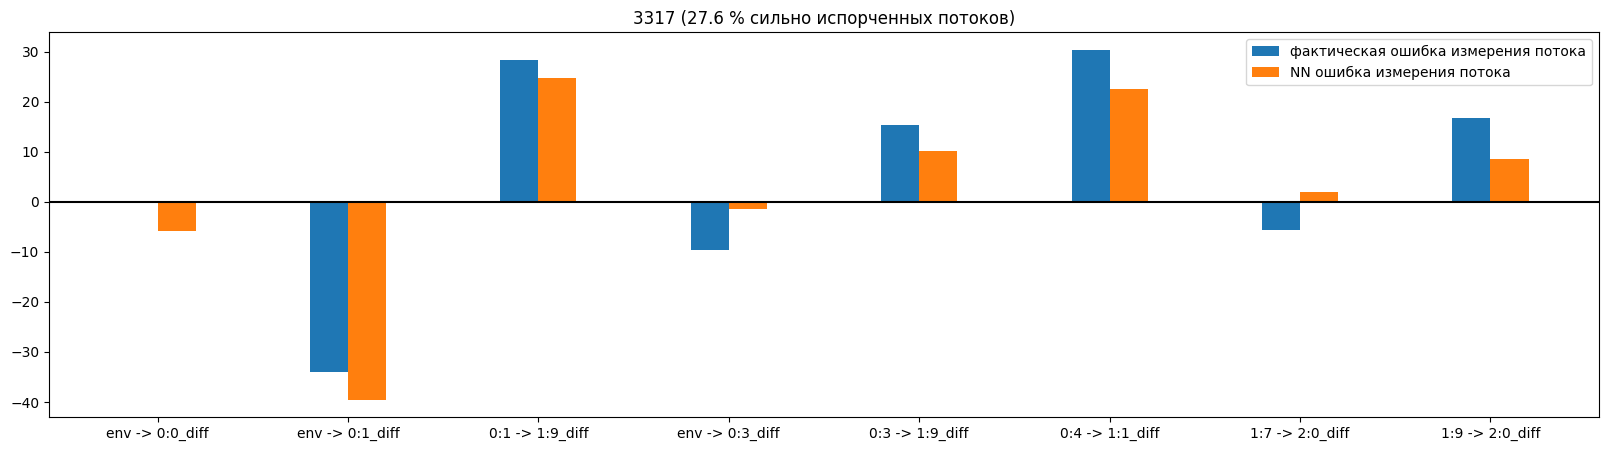

3866


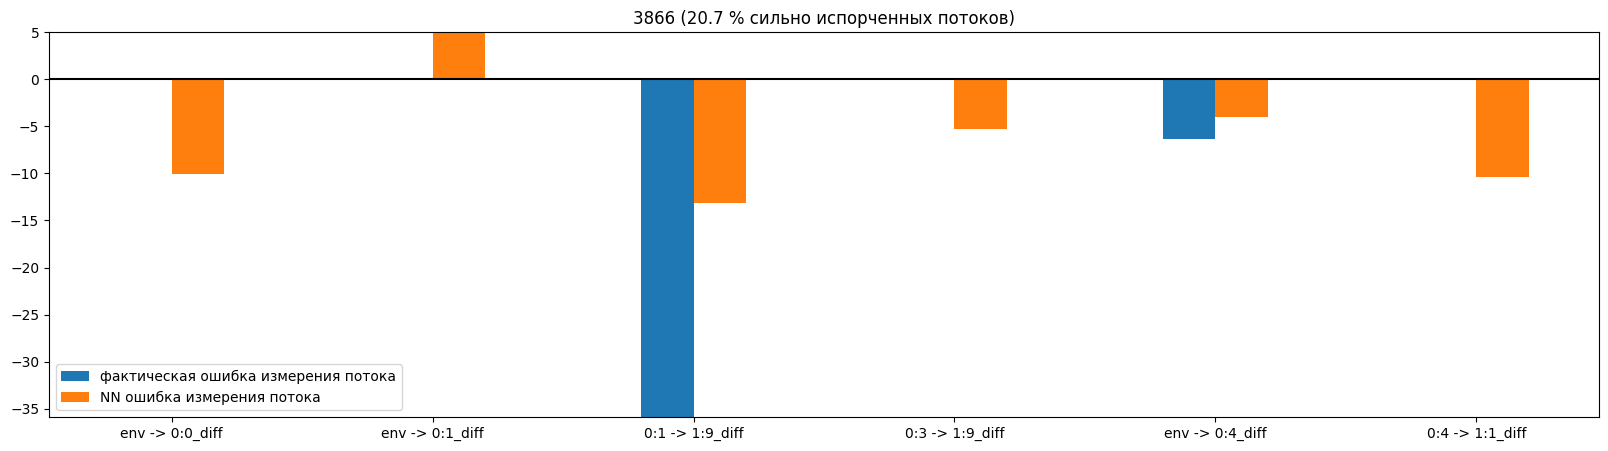

4252


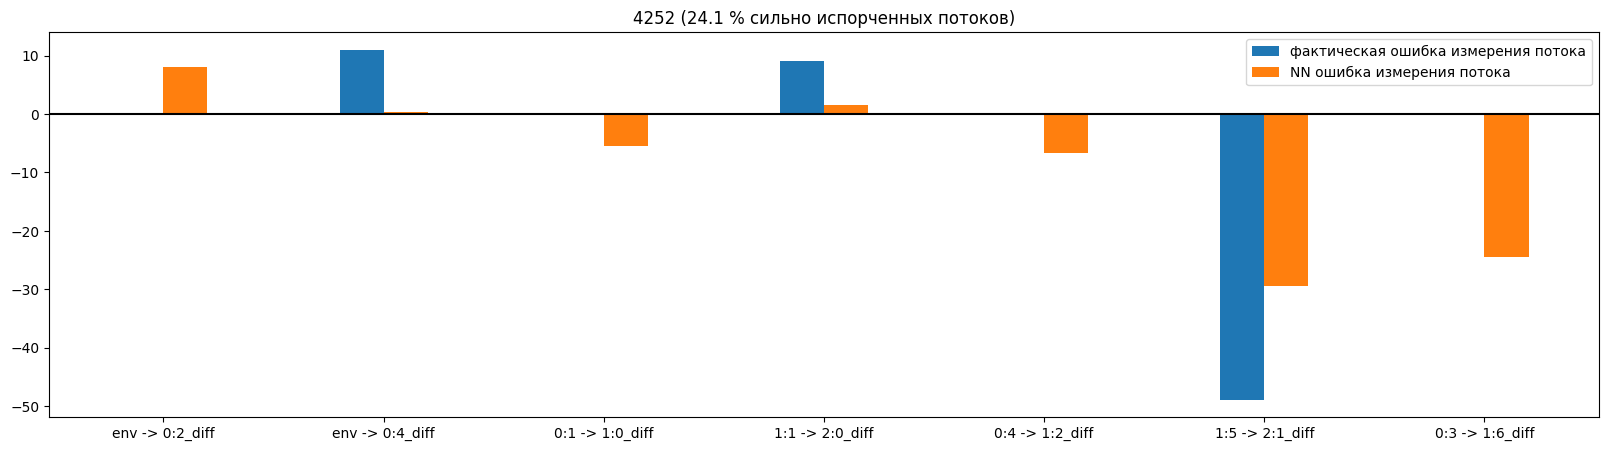

3229


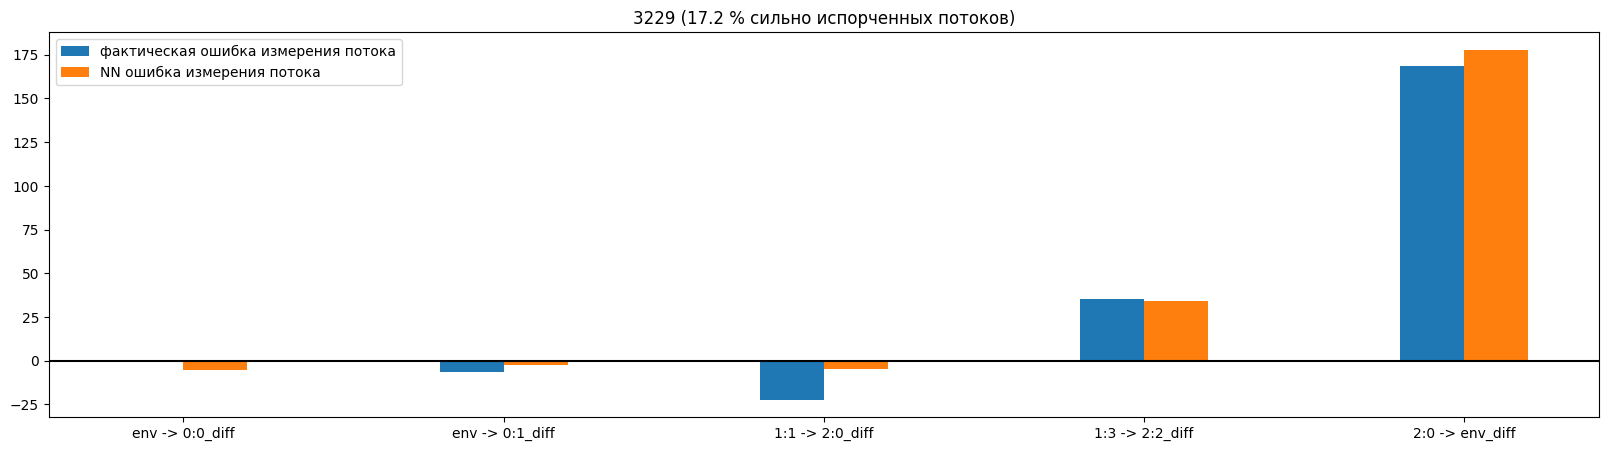

3512


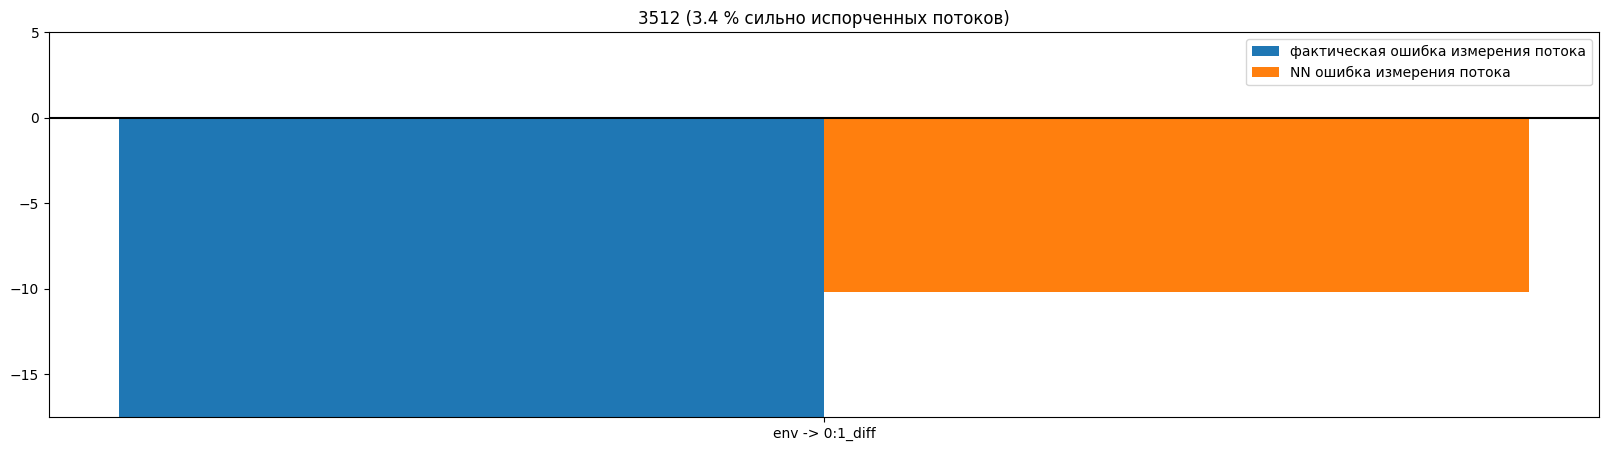

In [95]:
d1 = df_test.sample(10)[y_cols]
d = df_test_y_pred[y_cols]
th = 5

for i1, row1 in d1.iterrows():
    plt.figure(figsize=(20, 5))
    print(i1)
    row2 = d[d.index == i1].iloc[0]
    mask = [(abs(r1) > th) or (abs(r2) > th) for r1, r2 in zip(row1, row2)]
    row11 = row1[mask]
    row22 = row2[mask]
    w=.2
    indexes1 = [ii - w/2 for ii in range(len(row11.index))]
    indexes2 = [ii + w/2 for ii in range(len(row22.index))]
    plt.bar(indexes1, row11, width=w, label='фактическая ошибка измерения потока')
    plt.bar(indexes2, row22, width=w, label='NN ошибка измерения потока')
    plt.axhline(y=0, color='black')
    plt.xticks(range(len(row11)), row11.index)
    plt.title(f'{i1} ({(sum(mask) * 100 / len(row1)):<.1f} % сильно испорченных потоков)' )
    plt.legend()
    if row11.max() < th or row22.max() < th:
        plt.ylim((min(row1.min(), row2.min()), th))
    plt.show()

8.604047690728919
30.154745280264308


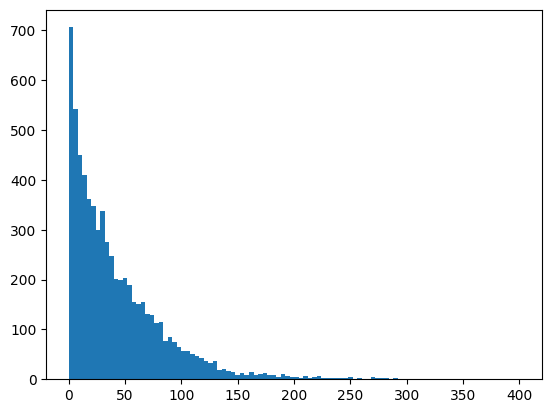

In [14]:
arr = np.array(df_test[y_cols])
x = arr[arr > 0]
plt.hist(x, bins=100)

middle_q = np.quantile(x, .2)
big_q = np.quantile(x, .5)

print(middle_q)
print(big_q)

In [15]:
from sklearn.metrics import r2_score, d2_absolute_error_score, mean_absolute_percentage_error

m1 = r2_score(df_test[y_cols], d[y_cols])
m2 = d2_absolute_error_score(df_test[y_cols], d[y_cols])

mx = df_test[y_cols]
mask_big_errors = df_test[y_cols] > big_q
m3 = mean_absolute_percentage_error(df_test[y_cols].where(df_test[y_cols] > middle_q, 0), 
                                    d[y_cols].where(df_test[y_cols] > middle_q, 0))

df_res = pd.DataFrame(
    {
        'metric': ['R2', 'D2', 'mape'],
        'score': [m1, m2, m3]
    }
)

df_res

,metric,score
0,R2,0.84
1,D2,0.42
2,mape,0.03


In [16]:
mask = (df_test[y_cols] > middle_q) #| (df_test[y_cols] < middle_q) #| \(d[y_cols] > middle_q) | (d[y_cols] < middle_q)

mask

,env -> 0:0_diff,0:0 -> 1:0_diff,env -> 0:1_diff,0:1 -> 1:2_diff,env -> 0:2_diff,0:2 -> 1:2_diff,env -> 0:3_diff,0:3 -> 1:1_diff,env -> 0:4_diff,0:4 -> 1:2_diff,1:0 -> env_diff,1:1 -> env_diff,1:2 -> env_diff
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False,True,False
3,False,False,False,False,True,False,False,False,False,True,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,True,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,True,False,False,False,False,True
4997,False,False,False,False,False,True,False,False,False,True,False,False,False
4998,False,False,False,False,True,False,False,False,False,False,False,False,False


In [17]:
mask = (df_test[y_cols] > middle_q) | (df_test[y_cols] < middle_q) | 
(d[y_cols] > middle_q) | (d[y_cols] < middle_q)

m1 = df_test[y_cols].where(mask, 0)
m2 = d.where(mask, 0)
x = np.array(df_test[y_cols] - d[y_cols]).flatten()

x = x[(x < big_q) | (x > big_q)]


SyntaxError: invalid syntax (2573929486.py, line 1)

In [ ]:

x = np.array(df_test[y_cols].where(mask, 0))
x = x.flatten()
x.sort()
x[x.nonzero()]



In [ ]:
big_q